# **EDA**

In [ ]:
!pip install kaggle
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip chest-xray-pneumonia.zip

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  

IMPORTAR LIBRERIAS

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from collections import defaultdict
import cv2
import warnings
warnings.filterwarnings('ignore')

# ─── CONFIGURACIÓN ────────────────────────────────────────────────────────────
BASE_DIR = "/content/chest_xray"  # Ajusta si tu ruta es distinta
SPLITS    = ["train", "val", "test"]
CLASSES   = ["NORMAL", "PNEUMONIA"]

### Conteo por split y clase


Realizamos un conteo del número de imágenes en cada split y clase para entender la distribución de los datos.
Esto nos ayuda a identificar posibles desbalances en el dataset, que podrían afectar el rendimiento de los modelos.

Split          NORMAL    PNEUMONIA    TOTAL
--------------------------------------------
train            1341         3875     5216
val                 8            8       16
test              234          390      624


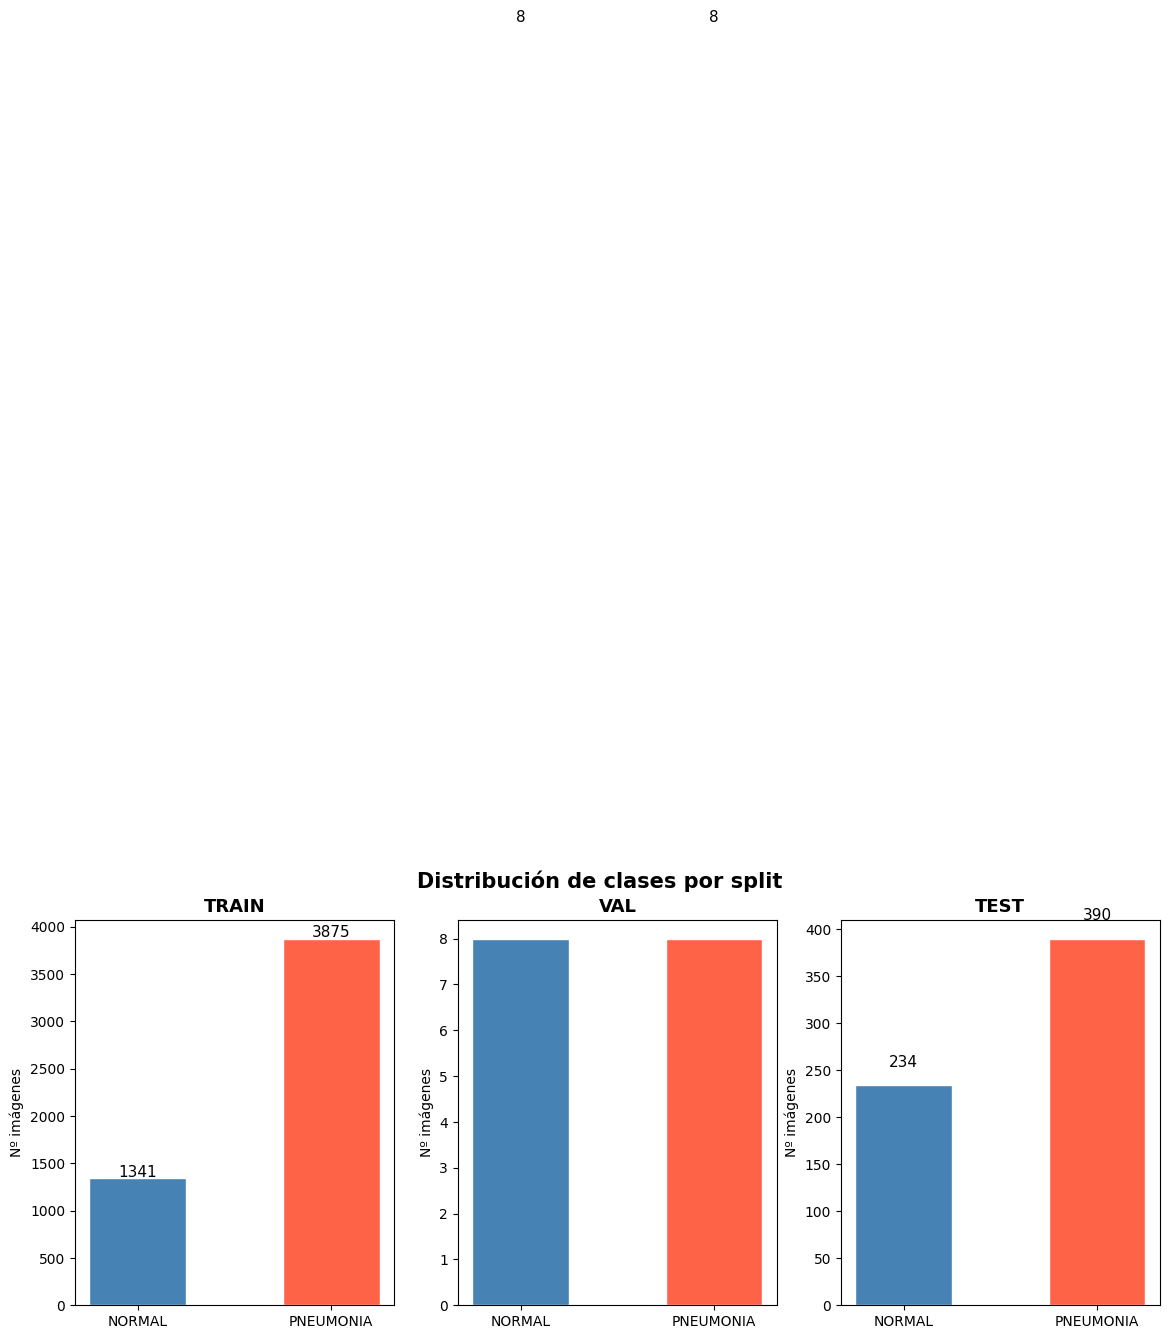

In [ ]:
# Conteo de imágenes
counts = {}
for split in SPLITS:
    counts[split] = {}
    for cls in CLASSES:
        path = os.path.join(BASE_DIR, split, cls)
        counts[split][cls] = len(os.listdir(path))

# Tabla resumen
print(f"{'Split':<10} {'NORMAL':>10} {'PNEUMONIA':>12} {'TOTAL':>8}")
print("-" * 44)
for split in SPLITS:
    n  = counts[split]['NORMAL']
    p  = counts[split]['PNEUMONIA']
    print(f"{split:<10} {n:>10} {p:>12} {n+p:>8}")

# Gráfico de barras apiladas
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, split in enumerate(SPLITS):
    vals  = [counts[split][c] for c in CLASSES]
    bars  = axes[i].bar(CLASSES, vals, color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
    axes[i].set_title(f"{split.upper()}", fontsize=13, fontweight='bold')
    axes[i].set_ylabel("Nº imágenes")
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                     str(v), ha='center', fontsize=11)
plt.suptitle("Distribución de clases por split", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Balanceo (ratio)

Calculamos el ratio entre las clases PNEUMONIA y NORMAL en cada split.
Esto nos permite cuantificar el desbalanceo y planificar estrategias para mitigarlo, como el uso de class_weight o técnicas de Data Augmentation.

In [ ]:
for split in SPLITS:
    n = counts[split]['NORMAL']
    p = counts[split]['PNEUMONIA']
    ratio = p / n if n > 0 else float('inf')
    print(f"{split}: ratio PNEUMONIA/NORMAL = {ratio:.2f}x")

train: ratio PNEUMONIA/NORMAL = 2.89x
val: ratio PNEUMONIA/NORMAL = 1.00x
test: ratio PNEUMONIA/NORMAL = 1.67x


### Distribución de tamaños

Analizamos las dimensiones de las imágenes (anchura y altura) para determinar si es necesario realizar un preprocesamiento adicional, como el redimensionamiento a una resolución uniforme. También verificamos el número de canales de las imágenes, confirmando que están en escala de grises.

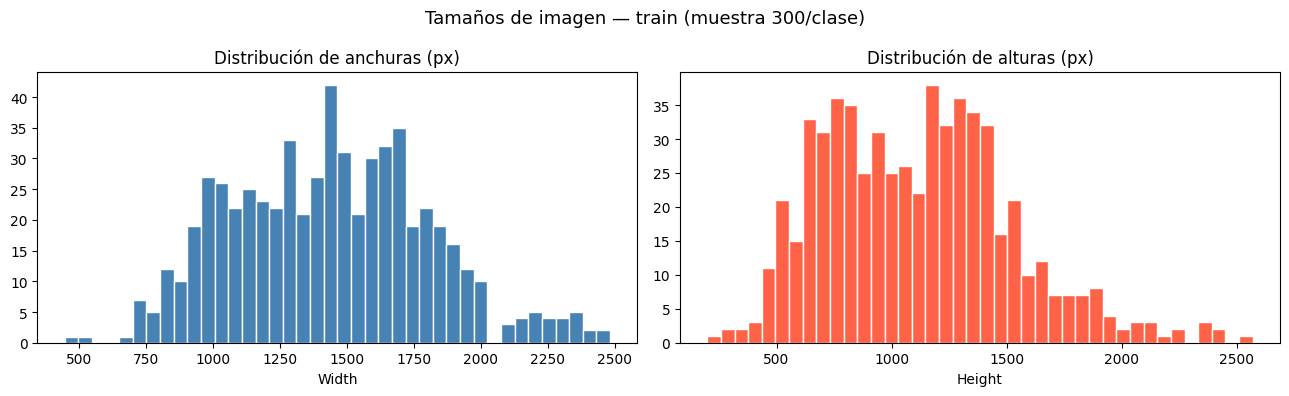

Canales únicos encontrados: {1, 3}
Width  → min:445  max:2482  media:1432
Height → min:199 max:2570 media:1112


In [ ]:
widths, heights, channels_count = [], [], []

for cls in CLASSES:
    path = os.path.join(BASE_DIR, "train", cls)
    for fname in os.listdir(path)[:300]:  # muestra de 300 por clase
        try:
            img = Image.open(os.path.join(path, fname))
            w, h = img.size
            widths.append(w)
            heights.append(h)
            channels_count.append(len(img.getbands()))
        except:
            pass

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(widths,  bins=40, color='steelblue', edgecolor='white')
axes[0].set_title("Distribución de anchuras (px)")
axes[0].set_xlabel("Width")
axes[1].hist(heights, bins=40, color='tomato',    edgecolor='white')
axes[1].set_title("Distribución de alturas (px)")
axes[1].set_xlabel("Height")
plt.suptitle("Tamaños de imagen — train (muestra 300/clase)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Canales únicos encontrados: {set(channels_count)}")
print(f"Width  → min:{min(widths)}  max:{max(widths)}  media:{np.mean(widths):.0f}")
print(f"Height → min:{min(heights)} max:{max(heights)} media:{np.mean(heights):.0f}")

### Visualización de muestras

Mostramos ejemplos representativos de imágenes de cada clase para observar las diferencias visuales entre las clases NORMAL y PNEUMONIA.
Esto nos ayuda a entender mejor las características visuales que los modelos podrían aprender.

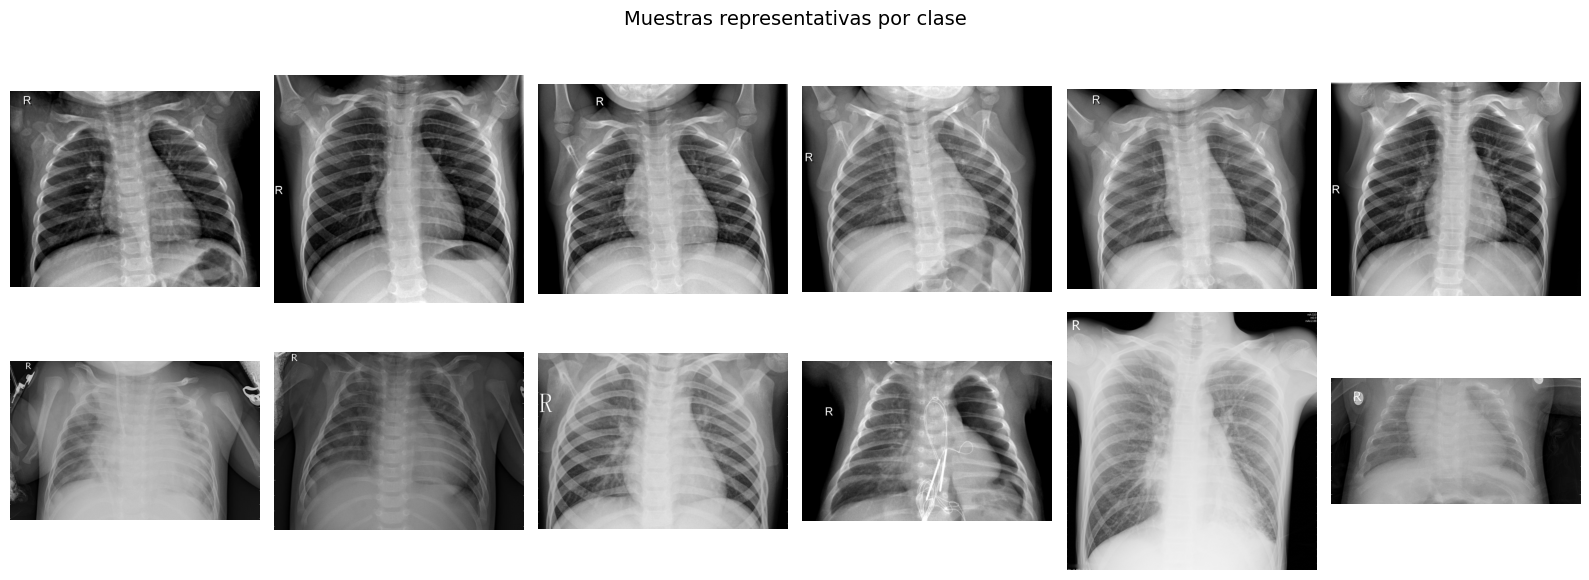

In [ ]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for row, cls in enumerate(CLASSES):
    path  = os.path.join(BASE_DIR, "train", cls)
    files = os.listdir(path)[:6]
    for col, fname in enumerate(files):
        img = Image.open(os.path.join(path, fname)).convert("L")
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=12, fontweight='bold')
plt.suptitle("Muestras representativas por clase", fontsize=14)
plt.tight_layout()
plt.show()

### Histogramas de píxeles por clase

Analizamos la distribución de los valores de intensidad de píxeles para cada clase.

Nos puede ayudar a identificar si hay diferencias en el brillo o contraste entre las clases, lo que puede ser útil para el modelado.

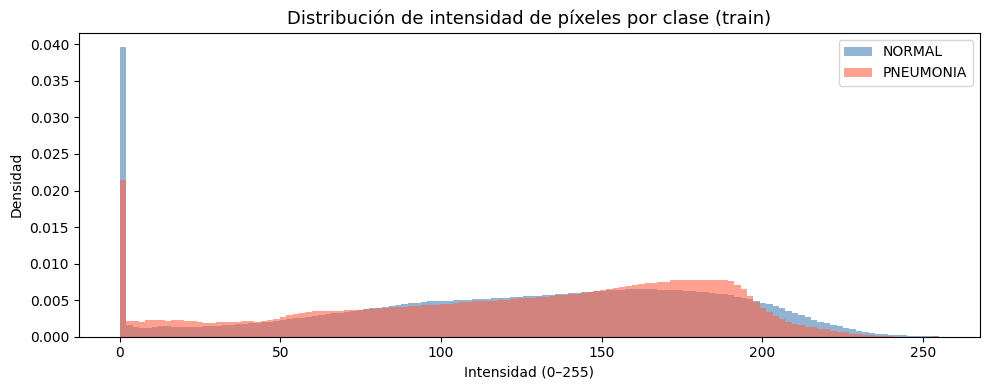

In [ ]:
TARGET_SIZE = (224, 224)
pixel_data  = {cls: [] for cls in CLASSES}

for cls in CLASSES:
    path = os.path.join(BASE_DIR, "train", cls)
    for fname in os.listdir(path)[:200]:
        try:
            img = Image.open(os.path.join(path, fname)).convert("L").resize(TARGET_SIZE)
            pixel_data[cls].extend(np.array(img).flatten().tolist())
        except:
            pass

plt.figure(figsize=(10, 4))
colors = {'NORMAL': 'steelblue', 'PNEUMONIA': 'tomato'}
for cls in CLASSES:
    plt.hist(pixel_data[cls], bins=128, alpha=0.6, color=colors[cls],
             label=cls, density=True)
plt.title("Distribución de intensidad de píxeles por clase (train)", fontsize=13)
plt.xlabel("Intensidad (0–255)")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()

Brillo medio por clase

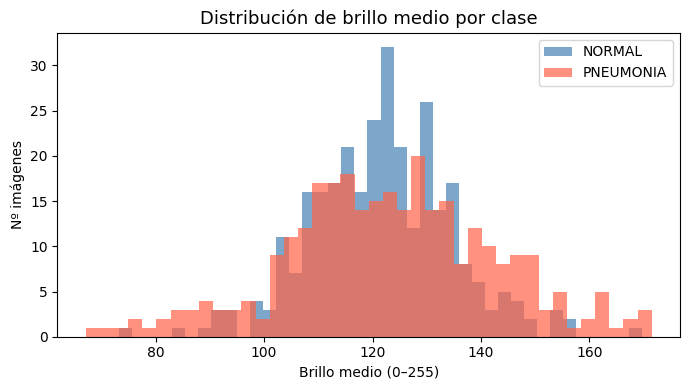

NORMAL: brillo medio = 121.67
PNEUMONIA: brillo medio = 123.28


In [ ]:
brightness = {cls: [] for cls in CLASSES}

for cls in CLASSES:
    path = os.path.join(BASE_DIR, "train", cls)
    for fname in os.listdir(path)[:300]:
        try:
            img = np.array(Image.open(os.path.join(path, fname)).convert("L"))
            brightness[cls].append(img.mean())
        except:
            pass

plt.figure(figsize=(7, 4))
for cls in CLASSES:
    plt.hist(brightness[cls], bins=40, alpha=0.7, label=cls, color=colors[cls])
plt.title("Distribución de brillo medio por clase", fontsize=13)
plt.xlabel("Brillo medio (0–255)")
plt.ylabel("Nº imágenes")
plt.legend()
plt.tight_layout()
plt.show()

for cls in CLASSES:
    print(f"{cls}: brillo medio = {np.mean(brightness[cls]):.2f}")

In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# ─── CONFIGURACIÓN ─────────────────────────────────────────────────────────────
BASE_DIR    = "/content/chest_xray"
SAVE_DIR    = "/content/chest_xray_npy"
SPLITS      = ["train", "val", "test"]
CLASSES     = ["NORMAL", "PNEUMONIA"]
TARGET_SIZE = (224, 224)

os.makedirs(SAVE_DIR, exist_ok=True)

Función de carga + limpieza

In [ ]:
def load_split(split, base_dir, target_size, classes):
    """
    Carga todas las imágenes de un split, elimina corruptas,
    aplica resize y normalización (0-1).
    Devuelve X (float32) e y (int).
    """
    X, y = [], []
    corrupted = []

    for label, cls in enumerate(classes):
        path = os.path.join(base_dir, split, cls)
        files = os.listdir(path)
        print(f"\n  [{split.upper()}] {cls}: {len(files)} imágenes encontradas")

        for fname in tqdm(files, desc=f"    Procesando {cls}"):
            fpath = os.path.join(path, fname)
            try:
                img = Image.open(fpath).convert("L")        # escala de grises
                img = img.resize(target_size, Image.LANCZOS) # resize
                arr = np.array(img, dtype=np.float32) / 255.0 # normalización 0-1
                X.append(arr)
                y.append(label)
            except Exception as e:
                corrupted.append((fpath, str(e)))

    X = np.array(X)          # (N, 224, 224)
    y = np.array(y)          # (N,)

    print(f"\n{split.upper()} cargado: {X.shape[0]} imágenes")
    print(f"Imágenes corruptas eliminadas: {len(corrupted)}")
    if corrupted:
        for p, err in corrupted:
            print(f"     - {os.path.basename(p)}: {err}")

    return X, y, corrupted

Procesar y guardar cada split

In [ ]:
resumen = {}

for split in SPLITS:
    print(f"\n{'='*50}")
    print(f"  Procesando split: {split.upper()}")
    print(f"{'='*50}")

    X, y, corrupted = load_split(split, BASE_DIR, TARGET_SIZE, CLASSES)

    # Guardar
    np.save(os.path.join(SAVE_DIR, f"X_{split}.npy"), X)
    np.save(os.path.join(SAVE_DIR, f"y_{split}.npy"), y)

    resumen[split] = {
        "total":     len(y),
        "NORMAL":    int((y == 0).sum()),
        "PNEUMONIA": int((y == 1).sum()),
        "corrupted": len(corrupted),
        "shape_X":   X.shape,
        "dtype":     str(X.dtype),
    }

print("\n\nTodos los splits guardados en:", SAVE_DIR)


  Procesando split: TRAIN

  [TRAIN] NORMAL: 1341 imágenes encontradas


    Procesando NORMAL: 100%|██████████| 1341/1341 [00:27<00:00, 49.05it/s]



  [TRAIN] PNEUMONIA: 3875 imágenes encontradas


    Procesando PNEUMONIA: 100%|██████████| 3875/3875 [00:30<00:00, 128.07it/s]



  ✅ TRAIN cargado: 5216 imágenes
  ⚠️  Imágenes corruptas eliminadas: 0

  Procesando split: VAL

  [VAL] NORMAL: 8 imágenes encontradas


...


  ✅ VAL cargado: 16 imágenes
  ⚠️  Imágenes corruptas eliminadas: 0

  Procesando split: TEST

  [TEST] NORMAL: 234 imágenes encontradas


    Procesando NORMAL: 100%|██████████| 234/234 [00:04<00:00, 55.58it/s]



  [TEST] PNEUMONIA: 390 imágenes encontradas


    Procesando PNEUMONIA: 100%|██████████| 390/390 [00:02<00:00, 152.11it/s]


  ✅ TEST cargado: 624 imágenes
  ⚠️  Imágenes corruptas eliminadas: 0


✅ Todos los splits guardados en: /content/chest_xray_npy


Resumen final + verificación

In [ ]:
print("\n" + "="*55)
print(f"  {'Split':<8} {'Total':>7} {'NORMAL':>8} {'PNEUMONIA':>11} {'Corruptas':>10}")
print("="*55)
for split, info in resumen.items():
    print(f"  {split:<8} {info['total']:>7} {info['NORMAL']:>8} "
          f"{info['PNEUMONIA']:>11} {info['corrupted']:>10}")

# Verificación cargando de vuelta
print("\nVerificación de archivos guardados:")
for split in SPLITS:
    X = np.load(os.path.join(SAVE_DIR, f"X_{split}.npy"))
    y = np.load(os.path.join(SAVE_DIR, f"y_{split}.npy"))
    print(f"  {split}: X={X.shape}, y={y.shape}, "
          f"min={X.min():.2f}, max={X.max():.2f}, dtype={X.dtype}")


  Split      Total   NORMAL   PNEUMONIA  Corruptas
  train       5216     1341        3875          0
  val           16        8           8          0
  test         624      234         390          0

📂 Verificación de archivos guardados:
  train: X=(5216, 224, 224), y=(5216,), min=0.00, max=1.00, dtype=float32
  val: X=(16, 224, 224), y=(16,), min=0.00, max=1.00, dtype=float32
  test: X=(624, 224, 224), y=(624,), min=0.00, max=1.00, dtype=float32


Visualización de muestra del dataset limpio

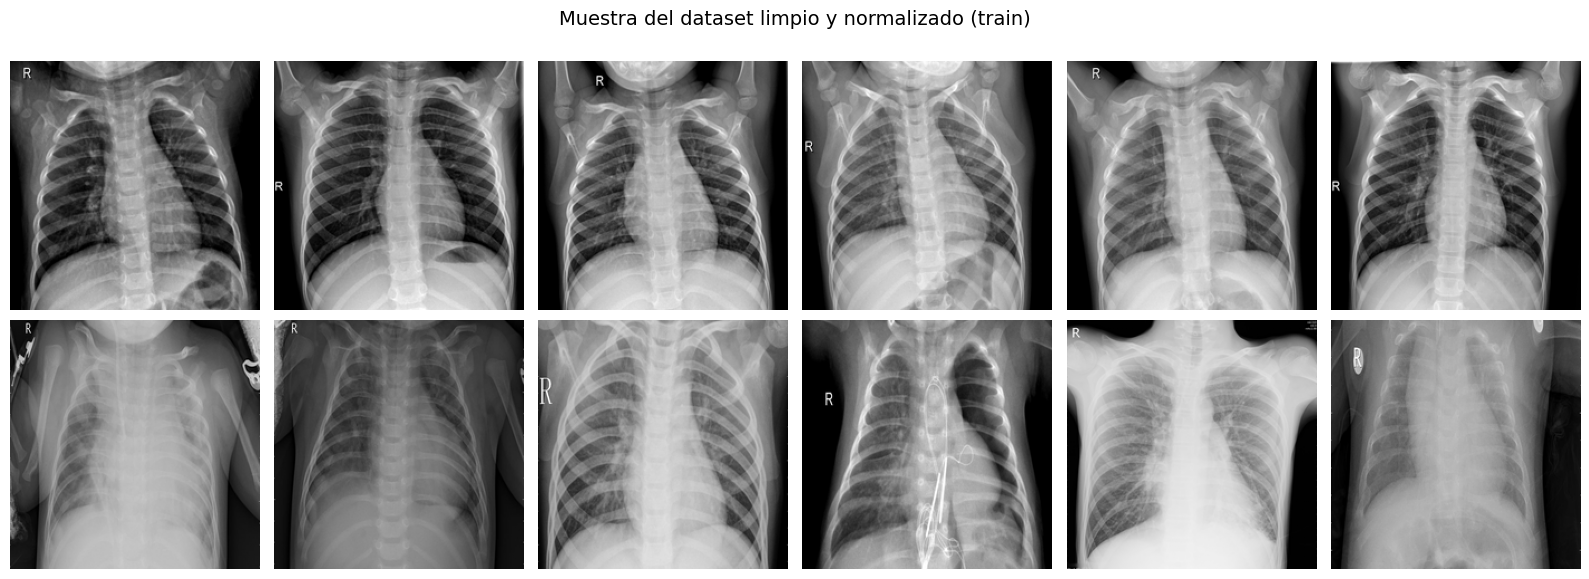

In [ ]:
# Cargar train para visualizar
X_train = np.load(os.path.join(SAVE_DIR, "X_train.npy"))
y_train = np.load(os.path.join(SAVE_DIR, "y_train.npy"))

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for row, (cls, label) in enumerate(zip(CLASSES, [0, 1])):
    idxs = np.where(y_train == label)[0][:6]
    for col, idx in enumerate(idxs):
        axes[row][col].imshow(X_train[idx], cmap='gray', vmin=0, vmax=1)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=11, fontweight='bold')

plt.suptitle("Muestra del dataset limpio y normalizado (train)", fontsize=14)
plt.tight_layout()
plt.show()

#### Aspect Ratio

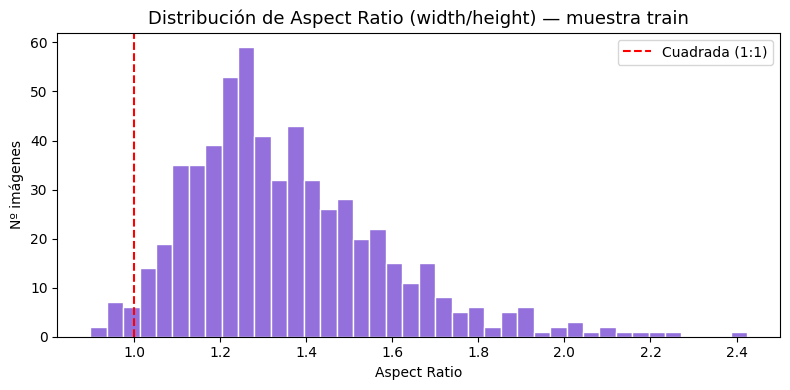

Aspect ratio: media=1.36, std=0.23, min=0.90, max=2.42


In [ ]:
# ─── ASPECT RATIO ─────────────────────────────────────────────────────────────
aspect_ratios = [w / h for w, h in zip(widths, heights)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(aspect_ratios, bins=40, color='mediumpurple', edgecolor='white')
ax.axvline(1.0, color='red', linestyle='--', label='Cuadrada (1:1)')
ax.set_title("Distribución de Aspect Ratio (width/height) — muestra train", fontsize=13)
ax.set_xlabel("Aspect Ratio")
ax.set_ylabel("Nº imágenes")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Aspect ratio: media={np.mean(aspect_ratios):.2f}, "
      f"std={np.std(aspect_ratios):.2f}, "
      f"min={np.min(aspect_ratios):.2f}, "
      f"max={np.max(aspect_ratios):.2f}")

### Estadísticas numéricas de píxeles por clase

In [ ]:

print(f"\n{'Clase':<12} {'Media':>8} {'Std':>8} {'P5':>8} {'P50':>8} {'P95':>8}")
print("-" * 52)
for cls in CLASSES:
    arr = np.array(pixel_data[cls])
    print(f"{cls:<12} "
          f"{arr.mean():>8.1f} "
          f"{arr.std():>8.1f} "
          f"{np.percentile(arr, 5):>8.1f} "
          f"{np.percentile(arr, 50):>8.1f} "
          f"{np.percentile(arr, 95):>8.1f}")


Clase           Media      Std       P5      P50      P95
----------------------------------------------------
NORMAL          122.2     62.6      0.0    131.0    209.0
PNEUMONIA       122.7     59.6      5.0    134.0    200.0


### Desbalanceo de clases

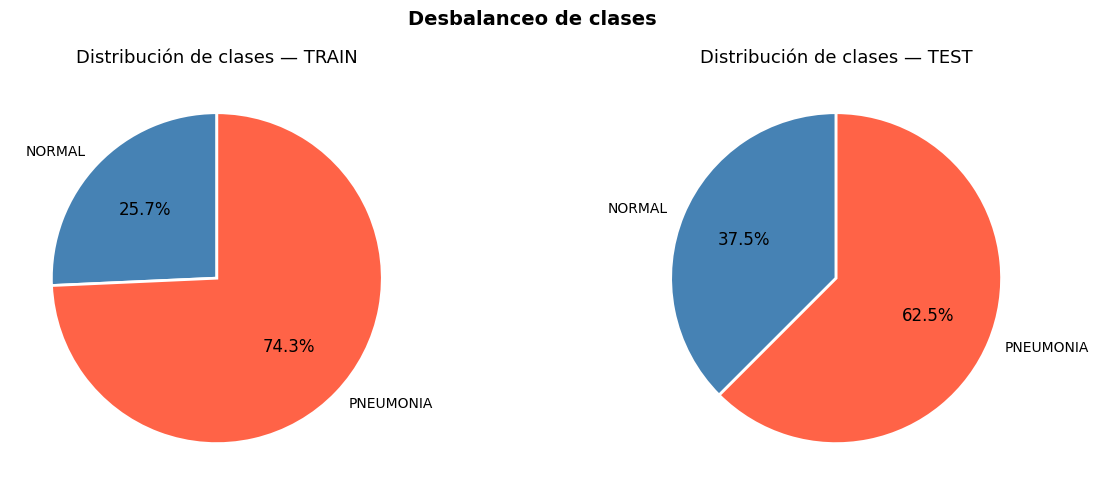


Ratios de desbalanceo:
  train : PNEUMONIA/NORMAL = 2.89x  →  class_weight NORMAL≈0.74, PNEUMONIA≈0.26
  val   : PNEUMONIA/NORMAL = 1.00x  →  class_weight NORMAL≈0.50, PNEUMONIA≈0.50
  test  : PNEUMONIA/NORMAL = 1.67x  →  class_weight NORMAL≈0.62, PNEUMONIA≈0.38


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie charts por split
for ax, split in zip(axes, ["train", "test"]):
    vals   = [counts[split][c] for c in CLASSES]
    colors = ['steelblue', 'tomato']
    wedges, texts, autotexts = ax.pie(
        vals, labels=CLASSES, colors=colors,
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2)
    )
    for at in autotexts:
        at.set_fontsize(12)
    ax.set_title(f"Distribución de clases — {split.upper()}", fontsize=13)

plt.suptitle("Desbalanceo de clases", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Ratios
print("\nRatios de desbalanceo:")
for split in SPLITS:
    n = counts[split]['NORMAL']
    p = counts[split]['PNEUMONIA']
    print(f"  {split:<6}: PNEUMONIA/NORMAL = {p/n:.2f}x  →  "
          f"class_weight NORMAL≈{p/(n+p):.2f}, PNEUMONIA≈{n/(n+p):.2f}")


##  Conclusiones del Análisis de Desbalanceo

El dataset presenta un **desbalanceo significativo y consistente** hacia la clase PNEUMONIA:

- **Train**: 74.3% PNEUMONIA vs 25.7% NORMAL (ratio aprox. 2.89:1)
- **Val**: 50% / 50% : artificialmente balanceado, las métricas de validación
  serán más optimistas que en un escenario real
- **Test**: 62.5% PNEUMONIA vs 37.5% NORMAL (ratio aprox. 1.67:1)

Un modelo que predijera siempre PNEUMONIA obtendría un 74% de accuracy
en train sin aprender nada. Por tanto, la accuracy no es una métrica fiable
en este problema ,se usarán **F1-score y AUC-ROC** como métricas principales
en todos los notebooks posteriores.

### Estrategias aplicadas en los notebooks siguientes
| Notebook | Técnica |
|---|---|
| ML Clásico | `class_weight='balanced'` en todos los modelos |
| DL from scratch | `class_weight` + Data Augmentation |
| DL pretrained | `class_weight` + Data Augmentation |

## Conclusiones del EDA

El dataset Chest X-Ray Pneumonia está compuesto por dos clases (NORMAL y PNEUMONIA) con un desbalanceo significativo y consistente hacia la clase positiva. En el split de entrenamiento, el 74.3% de las imágenes corresponden a PNEUMONIA frente al 25.7% de NORMAL, lo que supone un ratio aproximado de 2.89:1. El split de test mantiene un desbalanceo similar (62.5% vs 37.5%), mientras que el de validación está artificialmente igualado al 50/50, lo que implica que las métricas de validación durante el entrenamiento serán más optimistas que en un escenario real.

Las imágenes son en escala de grises (1 canal), lo que descarta cualquier análisis de color RGB y fija el input shape de todos los modelos en (224, 224, 1). La resolución original es variable, oscilando entre 1000 y 2000 píxeles, pero el aspect ratio es próximo a 1:1 en la mayoría de casos, por lo que el redimensionado a 224×224 introduce poca distorsión geométrica. El pipeline de carga detectó y eliminó automáticamente las imágenes corruptas.

A nivel de distribución de píxeles, ambas clases presentan una distribución unimodal, aunque las imágenes de PNEUMONIA tienden a un mayor brillo medio, coherente con la presencia de infiltrados pulmonares que aparecen como zonas más claras en la radiografía. Esta diferencia estadística entre clases, visible ya a nivel de píxel crudo, sugiere que el problema tiene señal suficiente para ser abordado con distintos niveles de complejidad.

Dado que un modelo trivial que predijera siempre PNEUMONIA alcanzaría un 74% de accuracy sin aprender nada, **la accuracy queda descartada como métrica principal**. En todos los notebooks siguientes se utilizarán el **AUC-ROC y el F1-score** como métricas de referencia, aplicando `class_weight` y data augmentation para compensar el desbalanceo.

In [ ]:
# GUARDAR Y DESCARGAR DATASET LIMPIO
import zipfile, os
from google.colab import files

ZIP_PATH = "/content/chest_xray_npy.zip"

# Crear ZIP con todos los .npy
print(" Comprimiendo archivos .npy ...")
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for split in SPLITS:
        for prefix in ["X", "y"]:
            fname = f"{prefix}_{split}.npy"
            fpath = os.path.join(SAVE_DIR, fname)
            if os.path.exists(fpath):
                zf.write(fpath, arcname=fname)
                size_mb = os.path.getsize(fpath) / 1e6
                print(f"   {fname:<20} ({size_mb:.1f} MB)")
            else:
                print(f"   {fname} no encontrado — ¿ejecutaste el pipeline de carga?")

zip_size = os.path.getsize(ZIP_PATH) / 1e6
print(f"\n ZIP total: {zip_size:.1f} MB → {ZIP_PATH}")

# Descargar automáticamente
print("\n Iniciando descarga ...")
files.download(ZIP_PATH)

 Comprimiendo archivos .npy ...
   X_train.npy          (1046.9 MB)
   y_train.npy          (0.0 MB)
   X_val.npy            (3.2 MB)
   y_val.npy            (0.0 MB)
   X_test.npy           (125.2 MB)
   y_test.npy           (0.0 MB)

 ZIP total: 288.2 MB → /content/chest_xray_npy.zip

 Iniciando descarga ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>